# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
data = {
    'Review': [
        "The new patch completely broke the meta. Healers are overpowered.",
        "Amazing graphics and smooth gameplay. Best RPG of the year.",
        "Server lag is ruining the experience. Unplayable during peak hours.",
        "Love the new expansion, but the grind for loot is way too long.",
        "Fantastic storyline, the characters are well written and the world is beautiful.",
        "Constant crashes after the new update. Needs a hotfix immediately.",
        "The combat mechanics are fluid and responsive. Top tier game.",
        "Too many microtransactions. The pay-to-win mechanics are obvious.",
        "Incredible soundtrack and voice acting. A true masterpiece.",
        "Matchmaking is completely broken. Keep getting paired with newbies."
    ],
    'Rating': [2, 5, 1, 3, 5, 1, 5, 2, 5, 2]
}
df = pd.DataFrame(data)
df.head()

,Review,Rating
0,The new patch completely broke the meta. Heale...,2
1,Amazing graphics and smooth gameplay. Best RPG...,5
2,Server lag is ruining the experience. Unplayab...,1
3,"Love the new expansion, but the grind for loot...",3
4,"Fantastic storyline, the characters are well w...",5


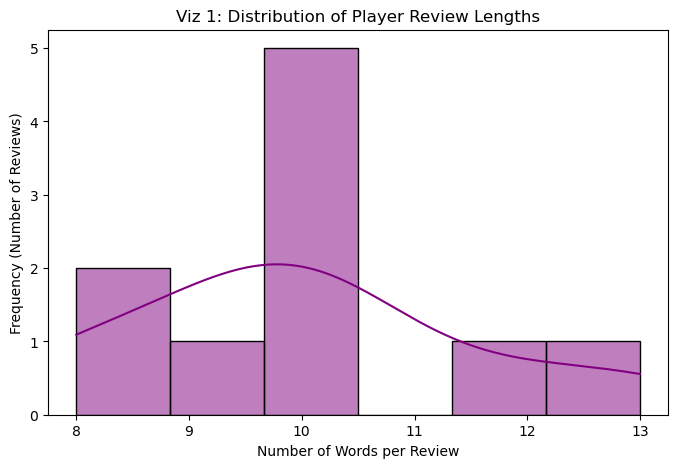

In [4]:
df['Word_Count'] = df['Review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 5))
sns.histplot(df['Word_Count'], bins=6, color='purple', kde=True)
plt.title("Viz 1: Distribution of Player Review Lengths")
plt.xlabel("Number of Words per Review")
plt.ylabel("Frequency (Number of Reviews)")
plt.show()

This histogram tracks the volume of text players are submitting. By plotting the word count distribution, we can see if the player base is dropping quick, reactionary feedback or writing massive, analytical essays about the patch. The KDE curve overlaid on the bars shows us the "average" length most players default to when posting their reviews.

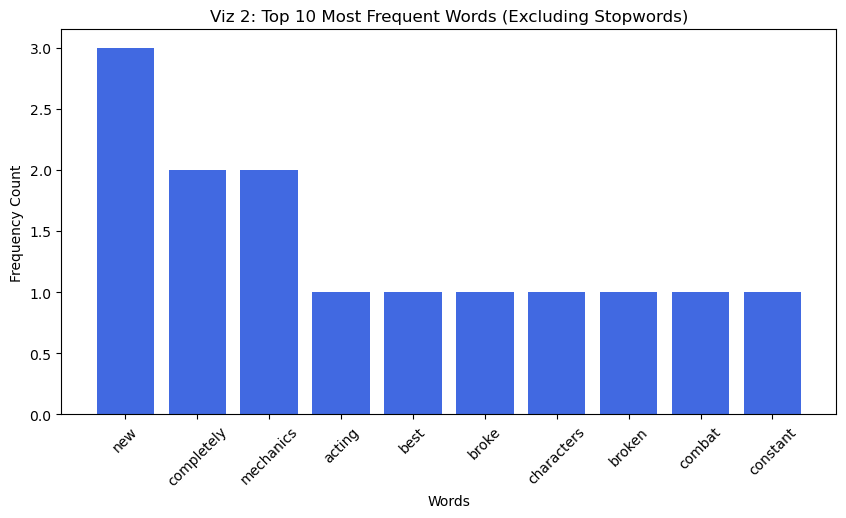

In [5]:
vec = CountVectorizer(stop_words='english')
matrix = vec.fit_transform(df['Review'])
word_freq = pd.DataFrame({'Word': vec.get_feature_names_out(), 'Frequency': matrix.toarray().sum(axis=0)})
word_freq = word_freq.sort_values(by='Frequency', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(word_freq['Word'], word_freq['Frequency'], color='royalblue')
plt.title("Viz 2: Top 10 Most Frequent Words (Excluding Stopwords)")
plt.xlabel("Words")
plt.ylabel("Frequency Count")
plt.xticks(rotation=45)
plt.show()

By stripping out standard English stopwords like "the", "and", "is" this bar chart provides a hard, quantitative breakdown of the exact word frequencies. It clearly visualizes that words like "mechanics" and "new" are the top drivers of conversation, giving us a data-driven look at the community's core focus areas without the noise of filler words.

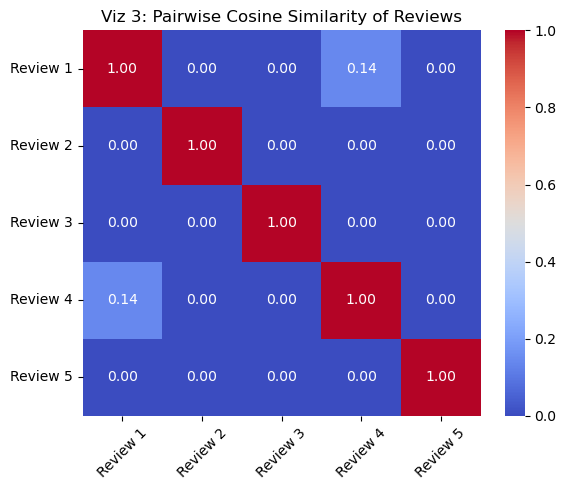

In [6]:
sample_reviews = df['Review'].head(5)
vec_sample = CountVectorizer(stop_words='english')
matrix_sample = vec_sample.fit_transform(sample_reviews)

sim_matrix = cosine_similarity(matrix_sample)

plt.figure(figsize=(6, 5))
sns.heatmap(sim_matrix, annot=True, cmap='coolwarm', fmt=".2f")

labels = [f"Review {i+1}" for i in range(5)]
plt.xticks(ticks=np.arange(5)+0.5, labels=labels, rotation=45)
plt.yticks(ticks=np.arange(5)+0.5, labels=labels, rotation=0)

plt.title("Viz 3: Pairwise Cosine Similarity of Reviews")
plt.tight_layout()
plt.show()

This heatmap maps out the mathematical cosine similarity between specific reviews to see if players are echoing the exact same sentiments. A higher score indicated by the darker red squares shows where text overlaps directly. Lighter blue squares indicate that the reviews share almost no overlapping vocabulary, meaning the players are discussing completely different aspects of the game update.